In [1]:
import os
import seaborn as sns
from rasterio.warp import reproject, Resampling
import glob
import pandas as pd
import matplotlib.pyplot as plt
import rasterio.features
import numpy as np
from matplotlib.patches import Patch

## SWE Data prep for analysis

In [ ]:
# dir1 = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1"
# dir2 = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2"
#
# task1 = []
# task2 = []
# for root, dirs, files in os.walk(dir1):
#     for directory in dirs:
#         task1.append(os.path.join(root, directory))
#
# for root, dirs, files in os.walk(dir2):
#     for directory in dirs:
#         task2.append(os.path.join(root, directory))
# print(task1)
# print("-------------------------------")
# print(task2)

In [ ]:
# def swe_units(task_dir):
#     for root, dirs, files in os.walk(task_dir):
#         for directory in dirs:
#             date = os.path.basename(directory)
#
#             if os.path.isfile(glob.glob(os.path.join(root,directory, "*EB_swe*"))[0]):
#                 with rasterio.open(glob.glob(os.path.join(root,directory, "*EB_swe*"))[0]) as src:
#                     data = src.read(1, masked=True)
#                     profile = src.profile
#                     profile.update(dtype=rasterio.float32, nodata=-9999)
#                     outfile = os.path.join(root,directory, f"{date}_EB_cm.tif")
#                     EB_cm = data * 2.54
#                 with rasterio.open(outfile, "w", **profile) as dst:
#                     dst.write(EB_cm.astype("float32"), 1)
#             else:
#                 print("No energy balance raster found")
#
#             if os.path.isfile(glob.glob(os.path.join(root,directory, "*TI_swe*"))[0]):
#                 with rasterio.open(glob.glob(os.path.join(root,directory, "*TI_swe*"))[0]) as src:
#                     data = src.read(1, masked=True)
#                     profile = src.profile
#                     profile.update(dtype=rasterio.float32, nodata=-9999)
#                     outfile = os.path.join(root,directory, f"{date}_TI_cm.tif")
#                     TI_cm = data * 2.54
#                 with rasterio.open(outfile, "w", **profile) as dst:
#                     dst.write(TI_cm.astype("float32"), 1)
#             else:
#                 print("No temperature index raster found")
#
#             if os.path.isfile(glob.glob(os.path.join(root,directory, "*swed*"))[0]):
#                 with rasterio.open(glob.glob(os.path.join(root,directory, "*swed*"))[0]) as src:
#                     data = src.read(1, masked=True)
#                     profile = src.profile
#                     profile.update(dtype=rasterio.float32, nodata=-9999)
#                     outfile = os.path.join(root,directory, f"{date}_SnowModel_cm.tif")
#                     SM_cm = data * 100
#                 with rasterio.open(outfile, "w", **profile) as dst:
#                     dst.write(SM_cm.astype("float32"), 1)
#             else:
#                 print("No SnowModel raster found")
#
#             if os.path.isfile(glob.glob(os.path.join(root,directory, "*specific_mass*"))[0]):
#                 with rasterio.open(glob.glob(os.path.join(root,directory, "*specific_mass*"))[0]) as src:
#                     data = src.read(1, masked=True)
#                     profile = src.profile
#                     profile.update(dtype=rasterio.float32, nodata=-9999)
#                     outfile = os.path.join(root,directory, f"{date}_iSnobal_cm.tif")
#                     iSnobal_cm = data / 10
#                 with rasterio.open(outfile, "w", **profile) as dst:
#                     dst.write(iSnobal_cm.astype("float32"), 1)
#             else:
#                 print("No iSnobal raster found")
#
#


In [ ]:
# swe_units("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2")
# swe_units("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1")

In [ ]:
# basin_shp = "C:/Users/RDCRLSMC/Desktop/GIS/basin/basin_outline.shp"
# with fiona.open(basin_shp, "r") as shapefile:
#     shapes = [feature["geometry"] for feature in shapefile]

In [ ]:
# def clip_basin(parent_dir):
#     target_string = 'cm'
#     for dir in parent_dir:
#         for root, dirs, files in os.walk(dir):
#             #print(files)
#             for filename in files:
#                 if target_string in filename:
#                     name, ext = os.path.splitext(filename)
#                     new_name = os.path.join(f"{name}_MC" + ext)
#                     out_path = os.path.join(dir, new_name)
#                     if os.path.exists(out_path):
#                         print(f"Skipping existing raster: {name}")
#                     else:
#                         with rasterio.open(os.path.join(dir, filename)) as src:
#                             out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)
# # Copy the old profile and update it with new metadata
#                             profile = src.profile
#                             profile.update({
#                             "driver": "GTiff",
#                             "height": out_image.shape[1],
#                             "width": out_image.shape[2],
#                             "transform": out_transform, # <-- Use the new transform from the mask operation
#                             "nodata": -9999 # Explicitly set nodata if not already
#                              })
#                         with rasterio.open(out_path, "w", **profile) as dest:
#                                 dest.write(out_image)


In [ ]:
# clip_basin(task1)
# clip_basin(task2)

In [2]:
def task_process(task_dir):
    swedata = {}
    for root, dirs, files in os.walk(task_dir):
        for directory in dirs:
            date = os.path.basename(directory)
            swedata[date] = {}
            swedata[date]["Energy Balance"] = glob.glob(os.path.join(root,directory, "*EB_cm_MC*"))[0]
            swedata[date]["Temperature Index"] = glob.glob(os.path.join(root,directory, "*TI_cm_MC*"))[0]
            swedata[date]["SnowModel"] = glob.glob(os.path.join(root,directory, "*SnowModel_cm_MC*"))[0]
            swedata[date]["iSnobal"] = glob.glob(os.path.join(root,directory, "*iSnobal_cm_MC*"))[0]
    return swedata

In [3]:
task2 = task_process("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task2")
task1 = task_process("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/SWE/Task1")

In [11]:
dem_100_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/shapes/dem_bil_100.tif"
dem_2000_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/shapes/dem_bil_2000.tif"

dfs = []


for key in task1.keys():
    task1_clip = task1[key]
    task2_clip = task2[key]

    MCS = {"Task 1":task1_clip, "Task 2":task2_clip}

    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
                with rasterio.open(model_data) as src:
                    ref_shape = (src.height, src.width)
                    ref_transform = src.transform
                    data = src.read(1)

                pixel_area_m2 = abs(ref_transform.a) * abs(ref_transform.e)
                print(f"{name} = {abs(ref_transform.a)}, {abs(ref_transform.e)}")
                elevation_aligned = np.empty(ref_shape, dtype=np.float32)

                if 'Energy Balance' in name or 'Temperature Index' in name:
                    with rasterio.open(dem_2000_fp) as dem:
                        reproject(
                            source=dem.read(1),
                            destination=elevation_aligned,
                            src_transform=dem.transform,
                            src_crs=dem.crs,
                            dst_transform=ref_transform,
                            dst_crs="EPSG:32611",
                            resampling=Resampling.nearest
                        )
                else:

                    with rasterio.open(dem_100_fp) as dem:
                        reproject(
                            source=dem.read(1),
                            destination=elevation_aligned,
                            src_transform=dem.transform,
                            src_crs=dem.crs,
                            dst_transform=ref_transform,
                            dst_crs="EPSG:32611",
                            resampling=Resampling.nearest
                        )

                invalid_snow = (data == -9999)
                invalid_elev = (elevation_aligned == 0)
                master_mask = invalid_snow | invalid_elev

                data_masked = np.ma.array(data, mask=master_mask)
                elevation_masked = np.ma.array(elevation_aligned, mask=master_mask)

                # Compress them (they are guaranteed to be the same length now)
                flattened = data_masked.compressed() * 10
                elevation_flat = elevation_masked.compressed()

                #Need to build elevation bins for plotting
                min = np.floor(elevation_flat.min() / 100) * 100
                max = np.ceil(elevation_flat.max() / 100) * 100
                edges = np.arange(min, max + 100, 100)

                ##create bin for grouping
                elevation_bin = pd.cut(elevation_flat, bins=edges)

                # and find midpoint for plotting
                elevation_plot = elevation_bin.map(lambda x: x.mid).astype(float)

                #Build dataframe
                df = pd.DataFrame({
                "Task":task,
                "Date":key,
                "Model": name,        # this column will store model names
                "SWE (mm)": flattened,
                "Elevation": elevation_flat,
                "Elevation Bin": elevation_bin,
                "Elevation plot": elevation_plot,
                        "Volume (m3)": (flattened / 1000.0) * pixel_area_m2
                })


                dfs.append(df)


swe = pd.concat(dfs, ignore_index=True)

Energy Balance = 2000.0, 2000.0
Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0
iSnobal = 100.0, 100.0
Energy Balance = 2000.0, 2000.0
Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0
iSnobal = 100.0, 100.0
Energy Balance = 2000.0, 2000.0
Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0


C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  elevation_plot = elevation_bin.map(lambda x: x.mid).astype(float)
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  elevation_plot = elevation_bin.map(lambda x: x.mid).astype(float)
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Pleas

iSnobal = 100.0, 100.0
Energy Balance = 2000.0, 2000.0
Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0
iSnobal = 100.0, 100.0
Energy Balance = 2000.0, 2000.0
Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0
iSnobal = 100.0, 100.0


C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  elevation_plot = elevation_bin.map(lambda x: x.mid).astype(float)
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  elevation_plot = elevation_bin.map(lambda x: x.mid).astype(float)
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Pleas

Energy Balance = 2000.0, 2000.0
Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0
iSnobal = 100.0, 100.0
Energy Balance = 2000.0, 2000.0
Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0
iSnobal = 100.0, 100.0
Energy Balance = 2000.0, 2000.0


C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  elevation_plot = elevation_bin.map(lambda x: x.mid).astype(float)
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  elevation_plot = elevation_bin.map(lambda x: x.mid).astype(float)
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Pleas

Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0
iSnobal = 100.0, 100.0
Energy Balance = 2000.0, 2000.0
Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0
iSnobal = 100.0, 100.0
Energy Balance = 2000.0, 2000.0
Temperature Index = 2000.0, 2000.0
SnowModel = 100.0, 100.0
iSnobal = 100.0, 100.0


C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_30384\1201081096.py:68: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  elevation_plot = elevation_bin.map(lambda x: x.mid).astype(float)


In [10]:
swe

,Task,Date,Model,SWE (mm),Elevation,Elevation Bin,Elevation plot,Volume (m3)
0,Task 1,20230405,Energy Balance,357.923157,1855.005737,"(1800.0, 1900.0]",1850.0,1.431693e+06
1,Task 1,20230405,Energy Balance,411.178589,1896.164429,"(1800.0, 1900.0]",1850.0,1.644714e+06
2,Task 1,20230405,Energy Balance,235.669922,1499.287842,"(1400.0, 1500.0]",1450.0,9.426797e+05
3,Task 1,20230405,Energy Balance,360.367584,1728.824951,"(1700.0, 1800.0]",1750.0,1.441470e+06
4,Task 1,20230405,Energy Balance,442.088684,1981.512817,"(1900.0, 2000.0]",1950.0,1.768355e+06
...,...,...,...,...,...,...,...,...
2063945,Task 2,20250501,iSnobal,0.000000,1446.490845,"(1400.0, 1500.0]",1450.0,0.000000e+00
2063946,Task 2,20250501,iSnobal,0.000000,1456.453735,"(1400.0, 1500.0]",1450.0,0.000000e+00
2063947,Task 2,20250501,iSnobal,0.000000,1446.656982,"(1400.0, 1500.0]",1450.0,0.000000e+00
2063948,Task 2,20250501,iSnobal,0.000000,1433.634521,"(1400.0, 1500.0]",1450.0,0.000000e+00


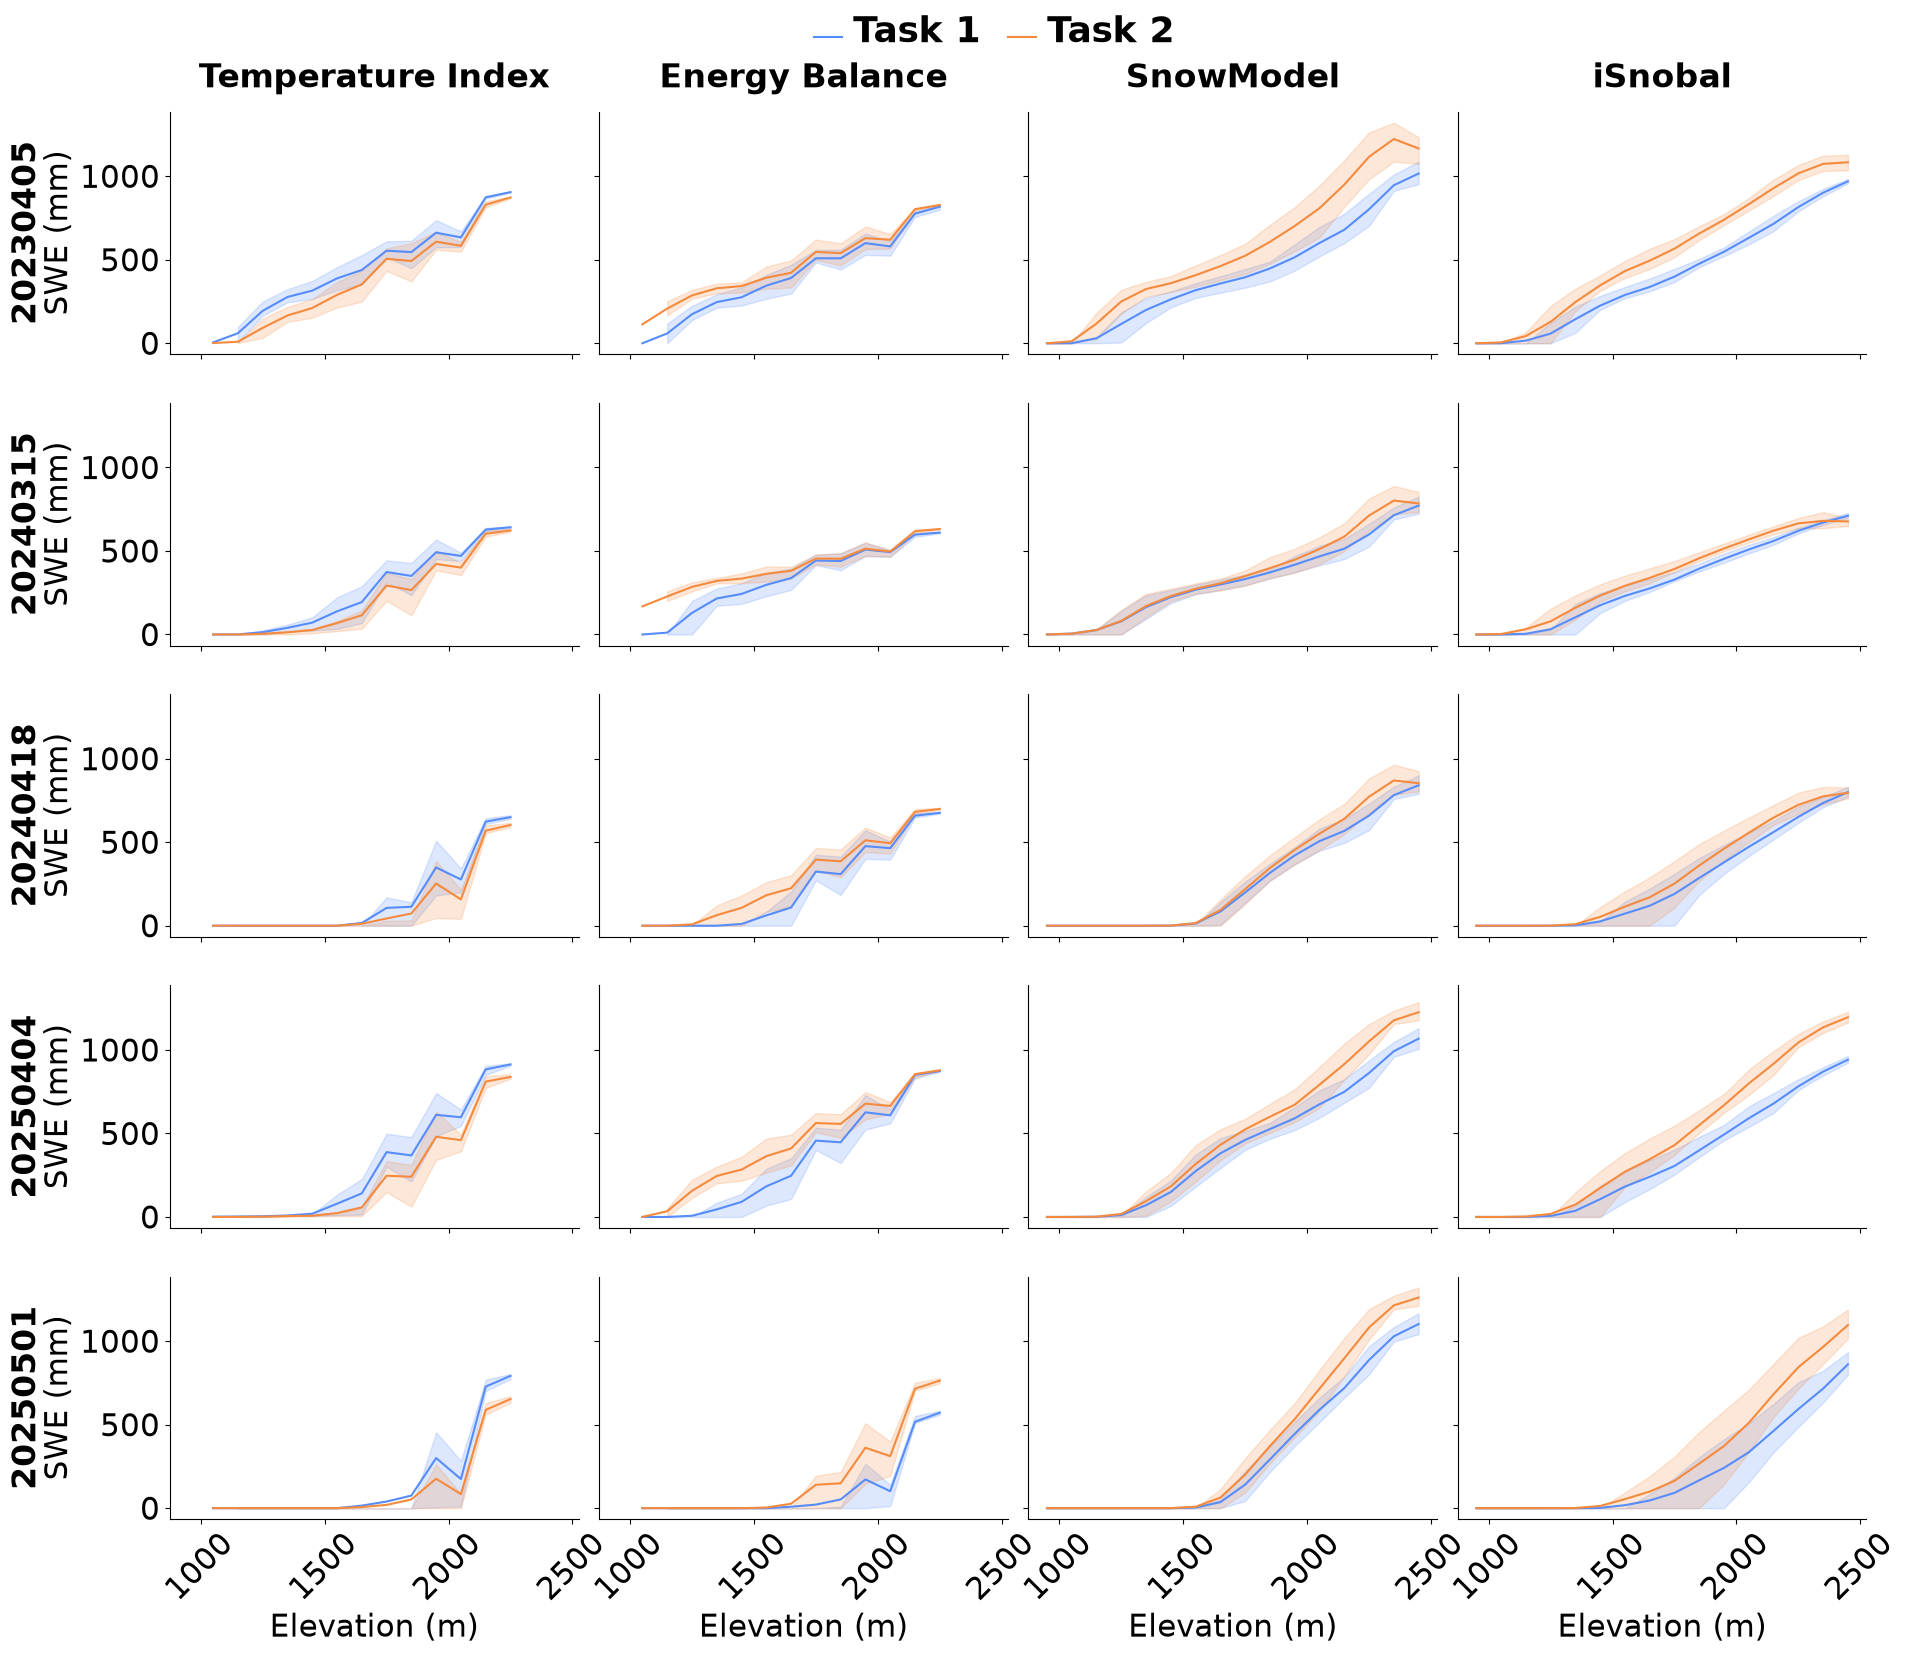

In [8]:

col_order = ['Temperature Index', 'Energy Balance', 'SnowModel', 'iSnobal']
row_order = sorted(swe['Date'].unique())

g = sns.relplot(
    data=swe,
    x='Elevation plot',
    y='SWE (mm)',
    row='Date',
    col='Model',
    row_order=row_order,
    col_order=col_order,
    hue='Task',
    kind='line',
    estimator='mean',
    errorbar=('pi', 50),
    height=3,
    aspect=1.5,
    facet_kws={'sharey': True, 'sharex': True}
)

g.figure.subplots_adjust(
    wspace=0.05,   # default is much larger (~0.2–0.3)
    hspace=0.2
)

# Optional: makes sure labels don't get clipped
g.set_axis_labels("Elevation (m)", "SWE (mm)", fontsize=22)
g.tick_params(axis='x', labelsize=22, rotation=45)
g.tick_params(axis='y', labelsize=22)
g.set_titles("")


row_labels = row_order
for i, ax in enumerate(g.axes[:, 0]):
    ax.annotate(
        row_labels[i],
        xy=(-.35, 0.5),
        xycoords='axes fraction',
        rotation=90,
        va='center',
        ha='center',
        fontsize=24,
        fontweight='bold'
    )

col_labels = col_order
for i, ax in enumerate(g.axes[0, :]):
    ax.annotate(
        col_labels[i],
        xy=(0.5, 1.1),
        xycoords='axes fraction',
        ha='center',
      #  va='bottom',
        fontsize=24,
        fontweight='bold'
    )

sns.move_legend(g, "upper center", bbox_to_anchor=(0.48, 1.05), ncol=2, markerscale=5)
plt.setp(g.legend.get_texts(), fontsize=26, fontweight='bold')
g.legend.set_title("")
plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/swe_ribbon_plots.png", dpi=300,
            bbox_inches="tight")
plt.show()

In [13]:
cum_swe

,Task,Date,Model,Elevation plot,Volume (m3),Cumulative Volume (TAF)
0,Task 1,20230405,Energy Balance,1050.0,0.000000e+00,0.000000
1,Task 1,20230405,Energy Balance,1150.0,3.053176e+06,2.475250
2,Task 1,20230405,Energy Balance,1250.0,1.669164e+07,16.007387
3,Task 1,20230405,Energy Balance,1350.0,4.633236e+07,53.569641
4,Task 1,20230405,Energy Balance,1450.0,5.510525e+07,98.244194
...,...,...,...,...,...,...
575,Task 2,20250501,iSnobal,2050.0,1.837762e+07,67.569511
576,Task 2,20250501,iSnobal,2150.0,1.753854e+07,81.788231
577,Task 2,20250501,iSnobal,2250.0,1.099541e+07,90.702354
578,Task 2,20250501,iSnobal,2350.0,6.470342e+06,95.947945


In [ ]:
ACRE_FT_TO_M3 = 1233.48

# Sum volume within each Task/Date/Model/elevation bin, then cumsum low->high elevation
cum_swe = (
    swe.groupby(['Task', 'Date', 'Model', 'Elevation plot'], as_index=False)['Volume (m3)']
    .sum()
    .sort_values(['Task', 'Date', 'Model', 'Elevation plot'])
)

#sum is in m^3
cum_swe['Cumulative Volume (TAF)'] = (
    cum_swe.groupby(['Task', 'Date', 'Model'])['Volume (m3)']
    .cumsum() / ACRE_FT_TO_M3 / 1000.0
)

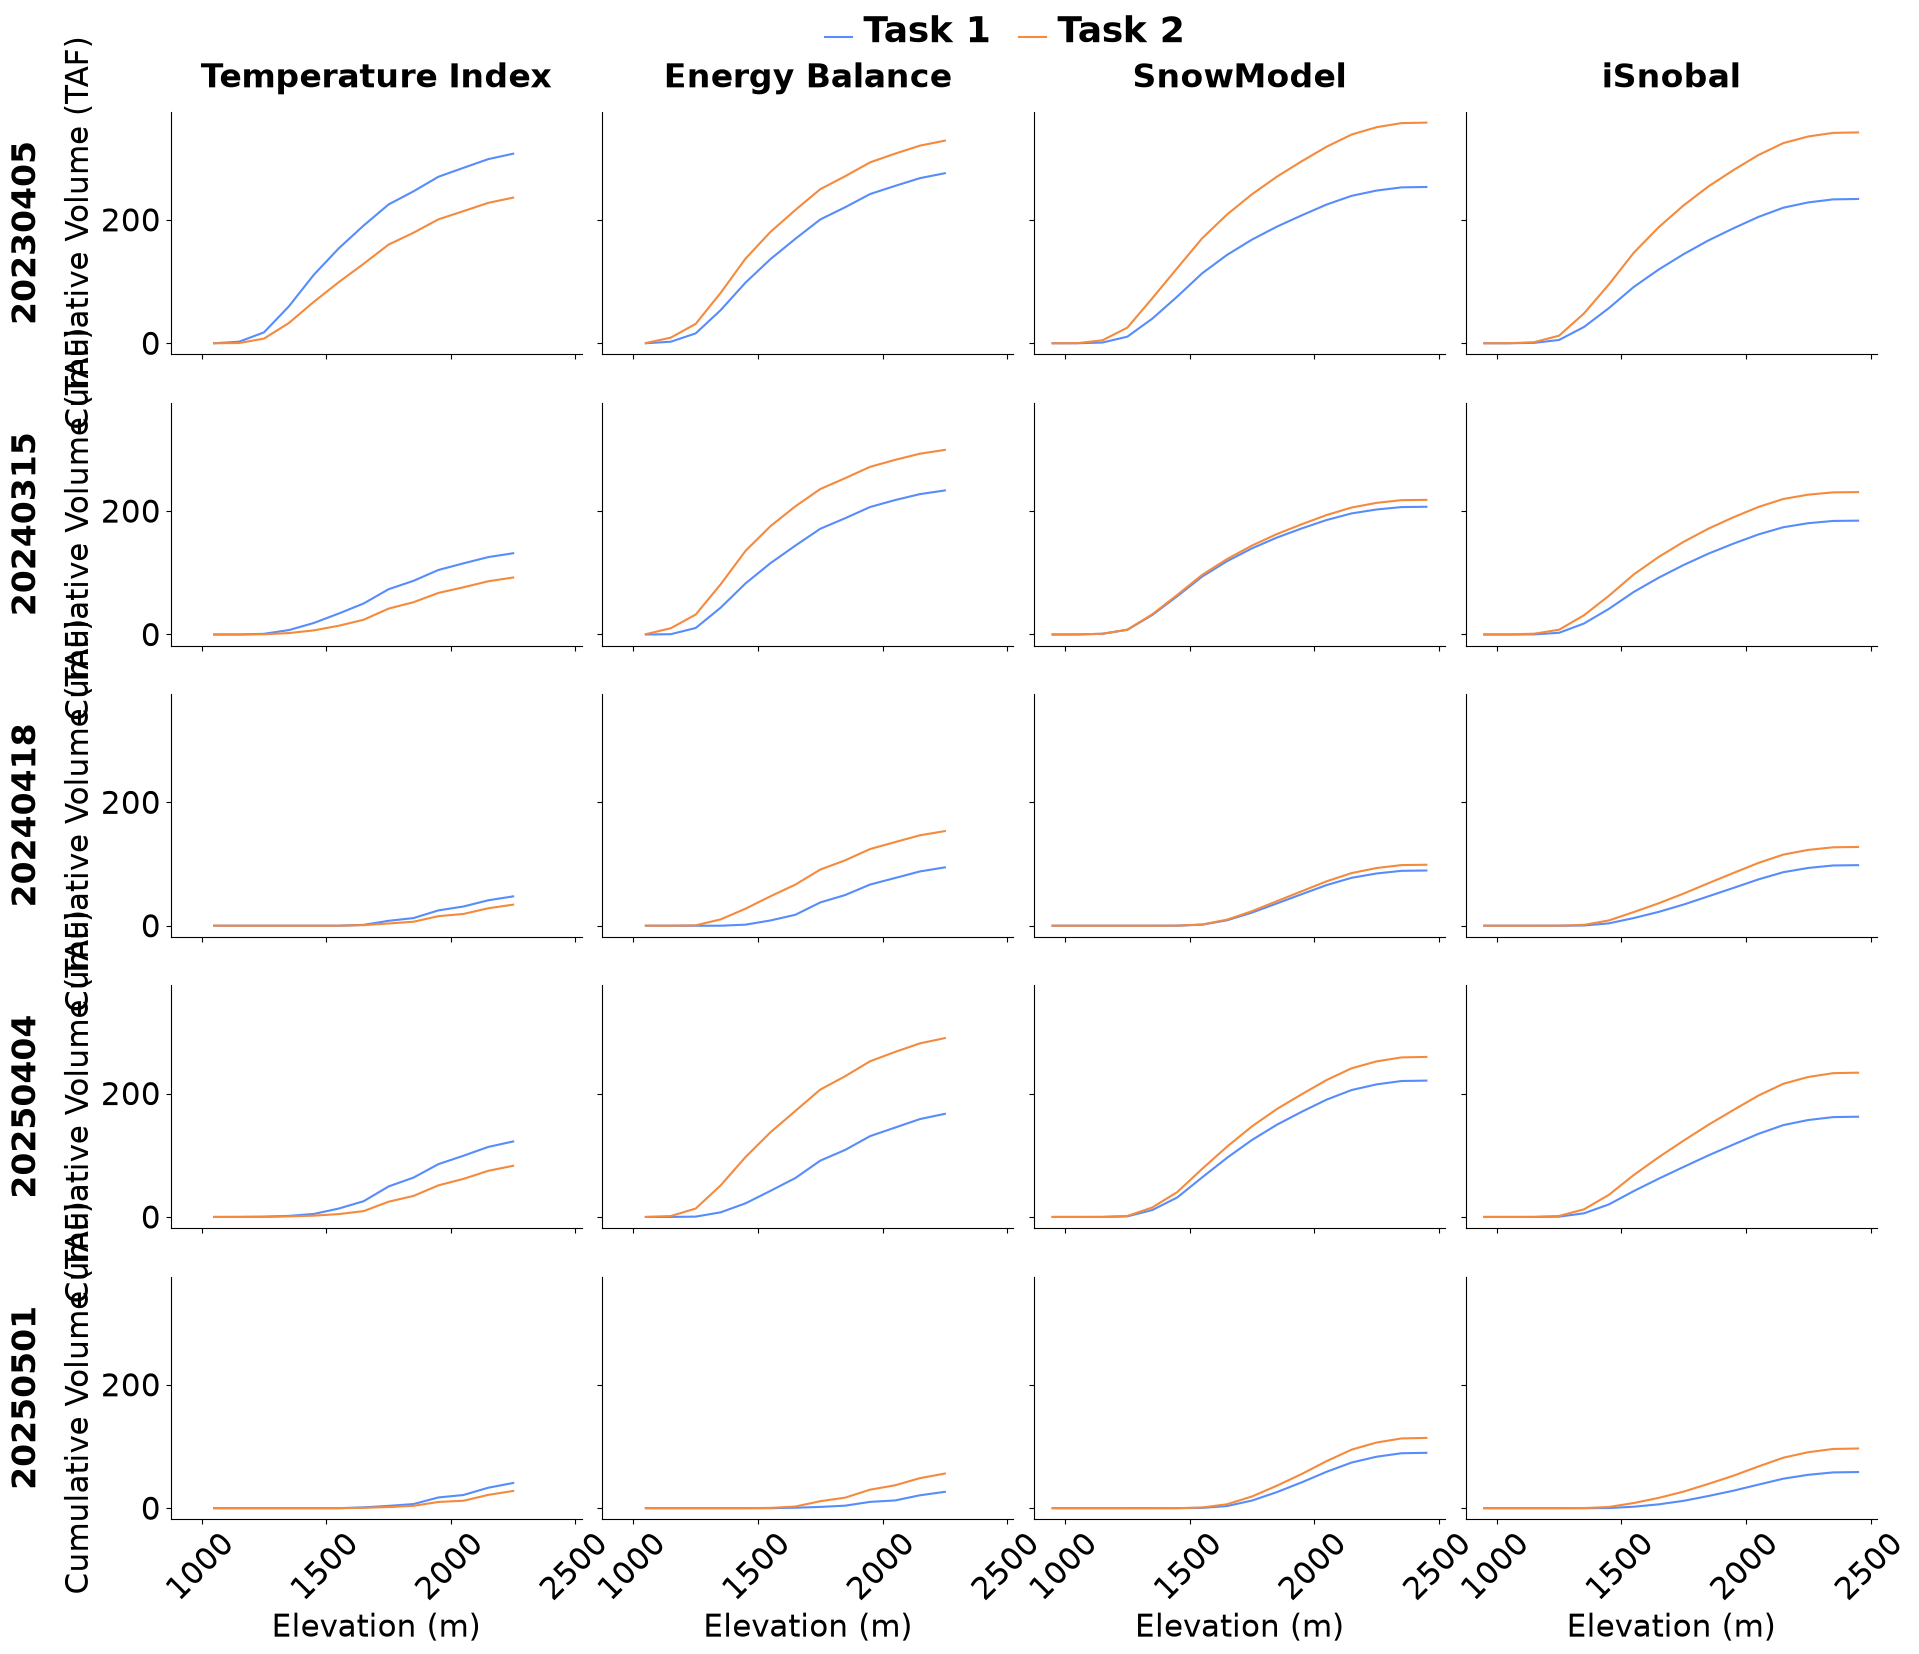

In [12]:
col_order = ['Temperature Index', 'Energy Balance', 'SnowModel', 'iSnobal']
row_order = sorted(cum_swe['Date'].unique())

g = sns.relplot(
    data=cum_swe,
    x='Elevation plot',
    y='Cumulative Volume (TAF)',
    row='Date',
    col='Model',
    row_order=row_order,
    col_order=col_order,
    hue='Task',
    kind='line',
    estimator=None,       # already aggregated to one value per bin -> no averaging needed
    height=3,
    aspect=1.5,
    facet_kws={'sharey': True, 'sharex': True}
)

g.figure.subplots_adjust(wspace=0.05, hspace=0.2)

g.set_axis_labels("Elevation (m)", "Cumulative Volume (TAF)", fontsize=22)
g.tick_params(axis='x', labelsize=22, rotation=45)
g.tick_params(axis='y', labelsize=22)
g.set_titles("")

for i, ax in enumerate(g.axes[:, 0]):
    ax.annotate(
        row_order[i], xy=(-.35, 0.5), xycoords='axes fraction',
        rotation=90, va='center', ha='center', fontsize=24, fontweight='bold'
    )

for i, ax in enumerate(g.axes[0, :]):
    ax.annotate(
        col_order[i], xy=(0.5, 1.1), xycoords='axes fraction',
        ha='center', fontsize=24, fontweight='bold'
    )

sns.move_legend(g, "upper center", bbox_to_anchor=(0.48, 1.05), ncol=2, markerscale=5)
plt.setp(g.legend.get_texts(), fontsize=26, fontweight='bold')
g.legend.set_title("")
plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/swe_cumulative_volume.png", dpi=300,
            bbox_inches="tight")
plt.show()

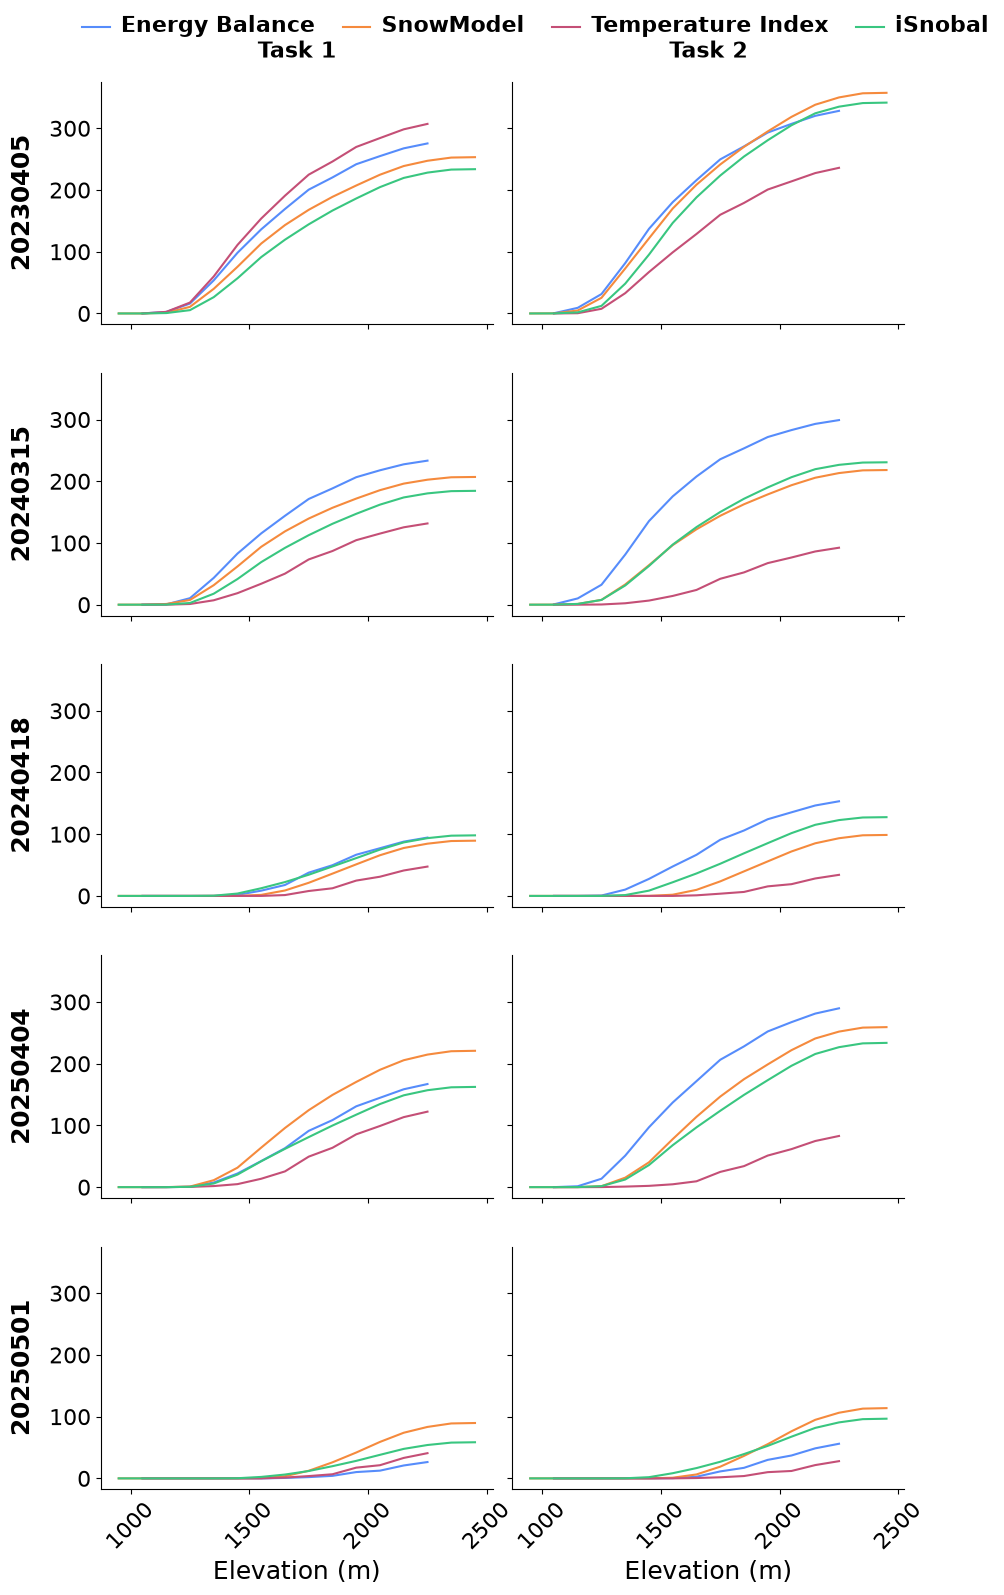

In [43]:
row_order = sorted(cum_swe['Date'].unique())
col_order = ['Task 1', 'Task 2']

g = sns.relplot(
    data=cum_swe,
    x='Elevation plot',
    y='Cumulative Volume (TAF)',
    row='Date',
    col='Task',
    row_order=row_order,
    col_order=col_order,
    hue='Model',
    kind='line',
    estimator=None,       # already aggregated to one value per bin -> no averaging needed
    height=3,
    aspect=1.5,
    facet_kws={'sharey': True, 'sharex': True}
)

g.figure.subplots_adjust(wspace=0.05, hspace=0.2)

g.set_axis_labels("Elevation (m)", "", fontsize=18)
g.tick_params(axis='x',
              labelsize=16,
              rotation=45
              )
g.tick_params(axis='y',
              labelsize=16
              )
g.set_titles("")

for i, ax in enumerate(g.axes[:, 0]):
    ax.annotate(
        row_order[i], xy=(-.2, 0.5), xycoords='axes fraction',
        rotation=90, va='center', ha='center',
        fontsize=18,
        fontweight='bold'
    )

for i, ax in enumerate(g.axes[0, :]):
    ax.annotate(
        col_order[i], xy=(0.5, 1.1), xycoords='axes fraction',
        ha='center',
        fontsize=16,
        fontweight='bold'
    )

sns.move_legend(g, "upper center", bbox_to_anchor=(0.48, 1.03),
                ncol=4,
                markerscale=5
                )
plt.setp(g.legend.get_texts(),
         fontsize=16,
         fontweight='bold'
         )
g.legend.set_title("")
plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/swe_cumulative_volume_comb.png", dpi=300,
            bbox_inches="tight")
plt.show()

In [44]:
volumes = []

for key in task1.keys():
    task1_clip = task1[key]
    task2_clip = task2[key]

    MCS = {"Task 1": task1_clip, "Task 2": task2_clip}

    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
            with rasterio.open(model_data) as src:
                pixel_area_m2 = abs(src.res[0] * src.res[1])
                data = src.read(1)

            valid_depth_cm = data[data != -9999]
            depth_m = valid_depth_cm / 100.0

            volume_m3 = np.sum(depth_m) * pixel_area_m2
            acre_feet = volume_m3 / 1233.48184
            kaf = acre_feet / 1000

            volumes.append({
                "Task": task,
                "Date": key,
                "Model": name,
                "KAF": kaf
            })

volumes_df = pd.DataFrame(volumes)

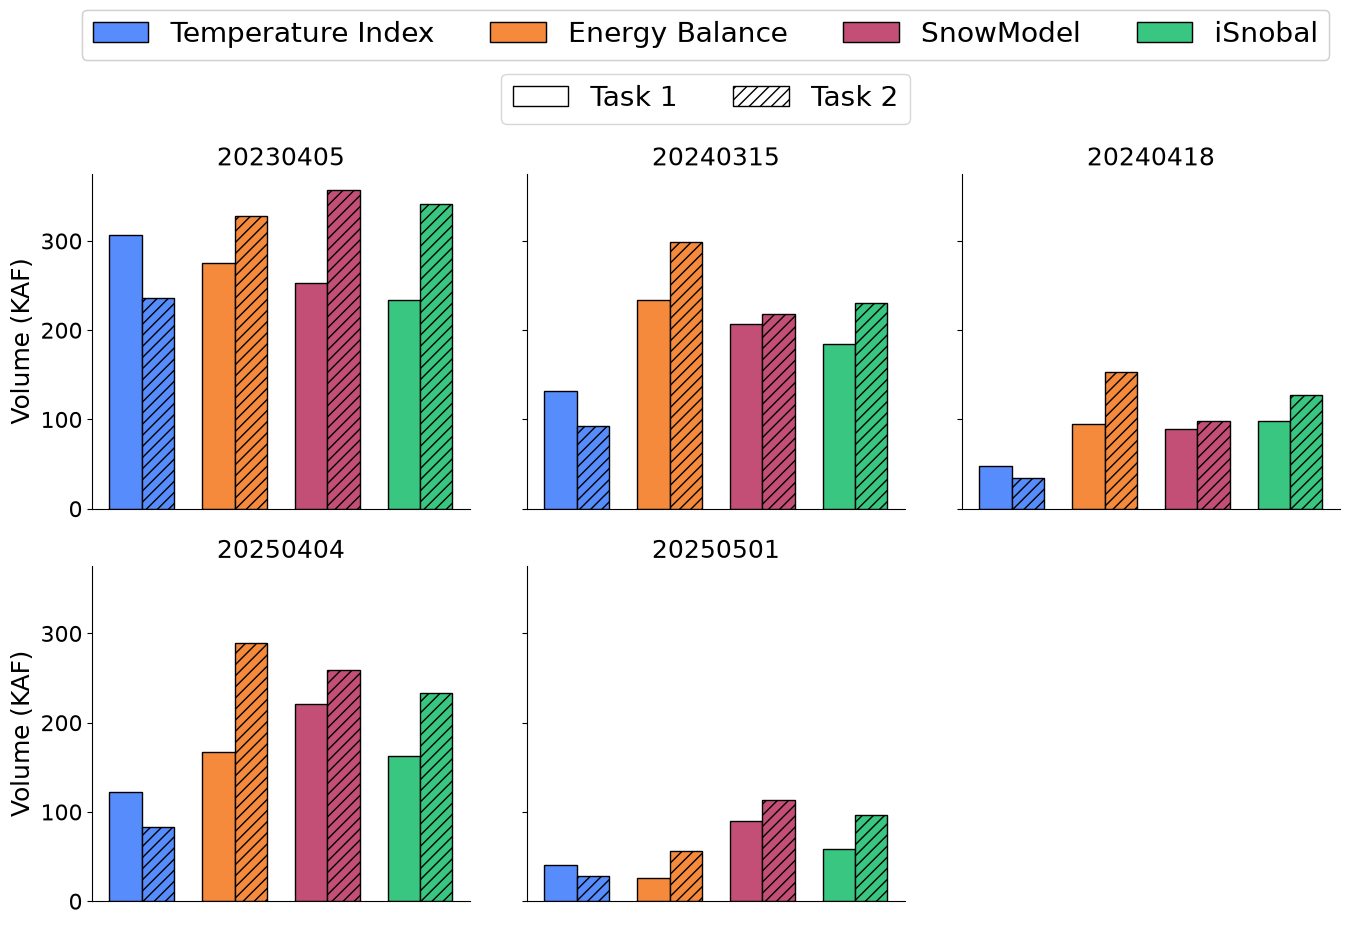

In [68]:
model_order = ['Temperature Index', 'Energy Balance', 'SnowModel', 'iSnobal']
task_order = ['Task 1', 'Task 2']

palette = sns.color_palette(n_colors=len(model_order))
model_colors = dict(zip(model_order, palette))

g = sns.FacetGrid(
    volumes_df,
    col='Date', col_wrap=3,
    height=4, aspect=1.1,
    sharey=True
)

bar_width = 0.35

for date_val, ax in g.axes_dict.items():
    sub = volumes_df[volumes_df['Date'] == date_val]
    ax.tick_params(axis='y', labelsize=16)
    for m_idx, model in enumerate(model_order):
        for t_idx, task in enumerate(task_order):
            row = sub[(sub['Model'] == model) & (sub['Task'] == task)]
            if row.empty:
                continue
            kaf_val = row['KAF'].values[0]
            x_pos = m_idx + (t_idx - 0.5) * bar_width
            bar = ax.bar(
                x_pos, kaf_val,
                width=bar_width,
                color=model_colors[model],
                edgecolor='black',
                hatch='///' if task == 'Task 2' else None
            )

ax.set_xticks([])
g.set_axis_labels("", "Volume (KAF)", fontsize=18
                  )
g.set_titles("{col_name}", size=18)
model_handles = [Patch(facecolor=model_colors[m], edgecolor='black', label=m) for m in model_order]
task_handles = [
    Patch(facecolor='white', edgecolor='black', label='Task 1'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='Task 2'),
]

# First legend (models)
legend1 = g.figure.legend(
    handles=model_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.18),
    ncol=len(model_order),
    fontsize=20
)
g.figure.add_artist(legend1)  # needed so the second legend() call doesn't remove this one

# Second legend (tasks), placed just below the first
g.figure.legend(
    handles=task_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.1),
    ncol=2,
    fontsize=20
)

plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/volume_bars.png", dpi=300, bbox_inches="tight")
plt.show()